# Association Rule Mining for Market Basket Analysis

## Part A: Data Preprocessing

In [56]:
import pandas as pd
import numpy as np
# Load CSVs
orders = pd.read_csv('orders.csv')
order_products_train = pd.read_csv('order_products__train.csv')

# Filter only 'train' orders
train_orders = orders[orders['eval_set'] == 'train']

# Merge to get only train set orders with their products
merged = pd.merge(train_orders, order_products_train, on='order_id')

# Group by order_id and form the set of product_ids for each order
transactions = merged.groupby('order_id')['product_id'].apply(list).reset_index()

# show first few
print(transactions.head())


   order_id                                         product_id
0         1  [49302, 11109, 10246, 49683, 43633, 13176, 472...
1        36  [39612, 19660, 49235, 43086, 46620, 34497, 486...
2        38  [11913, 18159, 4461, 21616, 23622, 32433, 2884...
3        96  [20574, 30391, 40706, 25610, 27966, 24489, 39275]
4        98  [8859, 19731, 43654, 13176, 4357, 37664, 34065...


In [57]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(transactions, test_size=0.2, random_state=42)

# Step 3: Save to CSV (optional)
train_set.to_csv('transactions_train.csv', index=False)
test_set.to_csv('transactions_test.csv', index=False)

print("\nTraining set size:", len(train_set))
print("Test set size:", len(test_set))


Training set size: 104967
Test set size: 26242


## Part B: Association Rule Mining

In [58]:
import ast
import math
from collections import Counter
from itertools import combinations

# ---------------------------
# Utility: load transactions
# ---------------------------
def load_transactions_from_csv(path, product_col='product_id'):
    """
    Expects CSV where product_col contains Python-style lists, e.g. "[123, 456, 789]".
    Returns: list of lists (transactions)
    """
    import pandas as pd
    df = pd.read_csv(path)
    trans = []
    for v in df[product_col].tolist():
        if isinstance(v, str):
            try:
                lst = ast.literal_eval(v)
            except Exception:
                # fallback: split by comma
                lst = [int(x.strip()) for x in v.split(',') if x.strip()!='']
        else:
            # already list-like (rare)
            lst = list(v)
        trans.append([str(x) for x in lst])  # convert to strings for consistency
    return trans


In [59]:
# ---------------------------
# APRIORI Implementation
# ---------------------------
def apriori(transactions, min_support=0.01):
    """
    Apriori algorithm (clean, correct, reasonably efficient).

    Args:
        transactions: list of transactions, where each transaction is an iterable of items (ints or strings).
        min_support: minimum support as fraction (e.g., 0.01)

    Returns:
        freq_sets: dict mapping tuple(sorted_items) -> support_count (int)
        T: total number of transactions (int)
    """
    import math
    from collections import Counter
    from itertools import combinations

    # Total transactions
    T = len(transactions)
    if T == 0:
        return {}, 0

    # Normalize transactions -> list of sets of strings (so items are hashable & consistent)
    trans_sets = [set(str(i) for i in t) for t in transactions]

    # Minimum support count (at least 1)
    min_support_count = max(1, math.ceil(min_support * T))

    # ---------- Frequent 1-itemsets ----------
    item_counts = Counter()
    for t in trans_sets:
        item_counts.update(t)  # counts each item once per transaction

    # L1: keep items meeting min support
    freq_sets = {}
    L_prev = set()
    for item, cnt in item_counts.items():
        if cnt >= min_support_count:
            freq_sets[(item,)] = cnt
            L_prev.add(frozenset([item]))

    # If no frequent 1-itemsets, return
    if not L_prev:
        return freq_sets, T

    # ---------- k-itemsets for k >= 2 ----------
    k = 2
    while L_prev:
        # Candidate generation (join step)
        candidates = set()
        L_prev_list = list(L_prev)
        n = len(L_prev_list)
        for i in range(n):
            for j in range(i + 1, n):
                union = L_prev_list[i] | L_prev_list[j]
                if len(union) == k:
                    candidates.add(union)

        # Prune: all (k-1)-subsets of a candidate must be frequent
        pruned_candidates = set()
        for cand in candidates:
            all_subsets_ok = True
            for subset in combinations(sorted(cand), k - 1):
                if frozenset(subset) not in L_prev:
                    all_subsets_ok = False
                    break
            if all_subsets_ok:
                pruned_candidates.add(cand)

        if not pruned_candidates:
            break

        # Count supports: for each transaction, enumerate k-combinations and increment if in candidate set
        cand_counts = Counter()
        pruned_candidates_lookup = set(pruned_candidates)  # frozensets
        for t in trans_sets:
            if len(t) < k:
                continue
            # generate combinations in a stable order
            for comb in combinations(sorted(t), k):
                comb_fs = frozenset(comb)
                if comb_fs in pruned_candidates_lookup:
                    cand_counts[comb_fs] += 1

        # Keep those meeting min support
        Lk = {}
        for cand_fs, cnt in cand_counts.items():
            if cnt >= min_support_count:
                Lk[cand_fs] = cnt

        if not Lk:
            break

        # Add to global freq_sets (use sorted tuple as key)
        for cand_fs, cnt in Lk.items():
            freq_sets[tuple(sorted(cand_fs))] = cnt

        # Prepare for next iteration
        L_prev = set(Lk.keys())
        k += 1

    return freq_sets, T


In [60]:
# ---------------------------
# FP-GROWTH Implementation
# ---------------------------
class FPTreeNode:
    def __init__(self, item, parent):
        self.item = item
        self.count = 0
        self.parent = parent
        self.children = {}
        self.link = None  # next node of same item (header table)

    def increment(self, n=1):
        self.count += n

def build_fp_tree(transactions, min_support_count):
    """
    Build FP-tree and header table.
    transactions: list of lists (items as strings)
    Returns: (root_node, header_table)
    header_table: dict item -> [total_count, head_node]
    """
    # First pass: count freq items
    item_counts = Counter()
    for t in transactions:
        for item in t:
            item_counts[item] += 1

    # Remove infrequent items
    freq_items = { item:cnt for item,cnt in item_counts.items() if cnt >= min_support_count }
    if not freq_items:
        return None, None

    # Header table: item -> [count, head_node]
    header_table = { item:[cnt, None] for item,cnt in freq_items.items() }

    # Order items in each transaction by descending frequency
    def sort_transaction(t):
        filtered = [i for i in t if i in freq_items]
        # sort by frequency desc then item to stabilize order
        filtered.sort(key=lambda x: (-freq_items[x], x))
        return filtered

    root = FPTreeNode(None, None)

    for t in transactions:
        ordered = sort_transaction(t)
        current = root
        for item in ordered:
            if item in current.children:
                node = current.children[item]
                node.increment(1)
            else:
                node = FPTreeNode(item, current)
                node.count = 1
                current.children[item] = node
                # update header table link
                head = header_table[item][1]
                if head is None:
                    header_table[item][1] = node
                else:
                    # append to link list
                    last = head
                    while last.link is not None:
                        last = last.link
                    last.link = node
            current = node
    return root, header_table

def ascend_fp_path(node):
    path = []
    current = node.parent
    while current and current.item is not None:
        path.append(current.item)
        current = current.parent
    path.reverse()
    return path

def find_conditional_pattern_base(item, header_table):
    """
    For a given item, traverse header_table to get its conditional pattern base:
    returns list of (prefix_path_list, count)
    """
    base = []
    node = header_table[item][1]
    while node is not None:
        if node.parent is not None:
            path = ascend_fp_path(node)
            if path:
                base.append((path, node.count))
        node = node.link
    return base

def mine_fp_tree(header_table, prefix, min_support_count, freq_itemsets):
    """
    Recursive mining on an FP-tree represented implicitly by header_table and
    building conditional trees.
    freq_itemsets: dict to collect itemset tuple -> support_count
    """
    # process items in increasing frequency order (as standard)
    items = sorted(header_table.items(), key=lambda x: x[1][0])  # (item, [count, head_node])
    for item, (support, headnode) in items:
        new_freq_set = prefix + [item]
        freq_itemsets[tuple(sorted(new_freq_set))] = support

        # Build conditional pattern base
        conditional_base = find_conditional_pattern_base(item, header_table)
        # Expand conditional transactions
        conditional_transactions = []
        for path, count in conditional_base:
            # add path count times
            for _ in range(count):
                conditional_transactions.append(path)

        # Build conditional FP-tree
        if conditional_transactions:
            cond_root, cond_header = build_fp_tree(conditional_transactions, min_support_count)
            if cond_header:
                mine_fp_tree(cond_header, new_freq_set, min_support_count, freq_itemsets)

def fpgrowth(transactions, min_support=0.01):
    """
    transactions: list of lists (items as strings)
    min_support: fraction
    Returns: (freq_itemsets, total_transactions)
    """
    transactions = [[str(i) for i in t] for t in transactions]
    T = len(transactions)
    min_support_count = math.ceil(min_support * T)

    root, header_table = build_fp_tree(transactions, min_support_count)
    if root is None:
        return {}, T

    freq_itemsets = {}
    mine_fp_tree(header_table, [], min_support_count, freq_itemsets)
    return freq_itemsets, T

In [61]:
# ---------------------------
# Association rules extraction (antecedent size == 1)
# ---------------------------
def generate_rules_singleton_antecedent(freq_itemsets, total_transactions, min_confidence=0.5):
    """
    freq_itemsets: dict mapping tuple(itemset) -> support_count
    total_transactions: int
    min_confidence: fraction
    Returns: list of rules as dicts:
       { 'antecedent': 'A', 'consequent': tuple(...), 'support': s_frac, 'confidence': c, 'lift': lift }
    Only rules where antecedent is single item are produced.
    """
    # Precompute support fractions
    support_frac = { k: v / total_transactions for k, v in freq_itemsets.items() }

    # Map singletons support
    single_support = {}
    for itemset, cnt in freq_itemsets.items():
        if len(itemset) == 1:
            single_support[itemset[0]] = cnt / total_transactions

    rules = []
    for itemset, cnt in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        s_itemset = cnt / total_transactions
        items = list(itemset)
        # antecedent must be single item: iterate item in items as potential antecedent
        for antecedent in items:
            antecedent_t = (antecedent,)
            consequent_items = tuple(sorted(set(items) - {antecedent}))
            if not consequent_items:
                continue
            support_ante = support_frac.get(antecedent_t)
            if support_ante is None:
                # fallback if singletons missing (shouldn't happen)
                support_ante = single_support.get(antecedent, 0.0)
            if support_ante == 0:
                continue
            confidence = s_itemset / support_ante
            if confidence >= min_confidence:
                # lift = confidence / support(consequent)?? (standard lift = support(X∪Y) / (support(X)*support(Y)))
                # compute support of consequent
                consequent_t = tuple(consequent_items)
                support_consequent = support_frac.get(consequent_t, None)
                # if consequent's exact itemset not in freq sets, approximate by computing product of singles (not ideal).
                if support_consequent is None:
                    # approximate or set to small value to avoid zero division
                    support_consequent = max(single_support.get(ci, 1e-9) for ci in consequent_items)
                lift = s_itemset / (support_ante * support_consequent) if (support_ante * support_consequent) > 0 else float('inf')

                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent_items,
                    'support': s_itemset,
                    'confidence': confidence,
                    'lift': lift
                })
    # sort by confidence desc
    rules.sort(key=lambda x: (-x['confidence'], -x['support']))
    return rules

In [62]:
transactions_csv = load_transactions_from_csv('transactions_train.csv', product_col='product_id')

print("Total transactions loaded:", len(transactions_csv))

# PARAMETERS
min_support = 0.005      # fraction e.g., 0.05 meaning 5%
min_confidence = 0.05

# ---- APRIORI ----
print("\nRunning Apriori ...")
apr_freq_sets, T = apriori(transactions_csv, min_support=min_support)
print("Apriori discovered {} frequent itemsets".format(len(apr_freq_sets)))

apr_rules = generate_rules_singleton_antecedent(apr_freq_sets, T, min_confidence=min_confidence)
# print("Apriori produced {} rules with singleton antecedent (min_confidence={})".format(len(apr_rules), min_confidence))

# Display top 10 apriori rules
print("\nTop Apriori rules:")
for r in apr_rules[:10]:
    print(f"  {{'{r['antecedent']}'}} -> {r['consequent']}, support={r['support']:.4f}, conf={r['confidence']:.4f}, lift={r['lift']:.4f}")

# ---- FP-GROWTH ----
print("\nRunning FP-Growth ...")
fpg_freq_sets, T2 = fpgrowth(transactions_csv, min_support=min_support)
print("FP-Growth discovered {} frequent itemsets".format(len(fpg_freq_sets)))

fpg_rules = generate_rules_singleton_antecedent(fpg_freq_sets, T2, min_confidence=min_confidence)
print("FP-Growth produced {} rules with singleton antecedent (min_confidence={})".format(len(fpg_rules), min_confidence))

# Display top 10 fpgrowth rules
print("\nTop FP-Growth rules:")
for r in fpg_rules[:10]:
    print(f"  {{'{r['antecedent']}'}} -> {r['consequent']}, support={r['support']:.4f}, conf={r['confidence']:.4f}, lift={r['lift']:.4f}")


Total transactions loaded: 104967

Running Apriori ...
Apriori discovered 370 frequent itemsets

Top Apriori rules:
  {'28204'} -> ('24852',), support=0.0092, conf=0.3666, lift=2.5741
  {'8174'} -> ('13176',), support=0.0055, conf=0.3640, lift=3.0732
  {'39928'} -> ('13176',), support=0.0050, conf=0.3555, lift=3.0008
  {'45066'} -> ('24852',), support=0.0092, conf=0.3416, lift=2.3984
  {'19057'} -> ('13176',), support=0.0076, conf=0.3396, lift=2.8669
  {'47209'} -> ('13176',), support=0.0184, conf=0.3303, lift=2.7880
  {'27966'} -> ('13176',), support=0.0135, conf=0.3192, lift=2.6946
  {'8424'} -> ('24852',), support=0.0070, conf=0.3169, lift=2.2249
  {'8277'} -> ('13176',), support=0.0053, conf=0.3090, lift=2.6083
  {'49683'} -> ('24852',), support=0.0056, conf=0.3084, lift=2.1656

Running FP-Growth ...
FP-Growth discovered 370 frequent itemsets
FP-Growth produced 199 rules with singleton antecedent (min_confidence=0.05)

Top FP-Growth rules:
  {'28204'} -> ('24852',), support=0.0092,

In [63]:
import matplotlib.pyplot as plt


def experiment_thresholds(transactions, algorithm='apriori'):
    """
    Runs Apriori or FP-Growth for multiple support/confidence values
    and plots number of rules discovered for each.
    """

    # Define the ranges to test
    min_sups = np.linspace(0.001, 0.01, 7)       # e.g. [0.001, 0.00325, ..., 0.01]
    min_confs = np.linspace(0.01, 0.1, 7)        # e.g. [0.01, 0.0325, ..., 0.1]

    results = np.zeros((len(min_sups), len(min_confs)))

    for i, sup in enumerate(min_sups):
        for j, conf in enumerate(min_confs):
            if algorithm == 'apriori':
                apr_freq_sets, T = apriori(transactions_csv, min_support=sup)
                rules = generate_rules_singleton_antecedent(apr_freq_sets, T, min_confidence=conf)

            elif algorithm == 'fp_growth':
                fpg_freq_sets, T2 = fpgrowth(transactions_csv, min_support=sup)
                rules = generate_rules_singleton_antecedent(fpg_freq_sets, T2, min_confidence=conf)
            else:
                raise ValueError("Algorithm must be 'apriori' or 'fp_growth'")

            results[i, j] = len(rules)
            print(f"{algorithm.upper()} | min_sup={sup:.4f}, min_conf={conf:.4f} => {len(rules)} rules")

    # --- Plot the results ---
    plt.figure(figsize=(8,6))
    plt.imshow(results, cmap='viridis', origin='lower')
    plt.colorbar(label='Number of Rules')
    plt.xticks(np.arange(len(min_confs)), [f"{c:.3f}" for c in min_confs])
    plt.yticks(np.arange(len(min_sups)), [f"{s:.3f}" for s in min_sups])
    plt.xlabel('Minimum Confidence')
    plt.ylabel('Minimum Support')
    plt.title(f'Rules Discovered ({algorithm.upper()})')
    plt.show()

    return results, min_sups, min_confs


APRIORI | min_sup=0.0010, min_conf=0.0100 => 5414 rules
APRIORI | min_sup=0.0010, min_conf=0.0250 => 4274 rules
APRIORI | min_sup=0.0010, min_conf=0.0400 => 3447 rules
APRIORI | min_sup=0.0010, min_conf=0.0550 => 2715 rules
APRIORI | min_sup=0.0010, min_conf=0.0700 => 2160 rules
APRIORI | min_sup=0.0010, min_conf=0.0850 => 1751 rules
APRIORI | min_sup=0.0010, min_conf=0.1000 => 1502 rules
APRIORI | min_sup=0.0025, min_conf=0.0100 => 975 rules
APRIORI | min_sup=0.0025, min_conf=0.0250 => 917 rules
APRIORI | min_sup=0.0025, min_conf=0.0400 => 816 rules
APRIORI | min_sup=0.0025, min_conf=0.0550 => 689 rules
APRIORI | min_sup=0.0025, min_conf=0.0700 => 604 rules
APRIORI | min_sup=0.0025, min_conf=0.0850 => 542 rules
APRIORI | min_sup=0.0025, min_conf=0.1000 => 481 rules
APRIORI | min_sup=0.0040, min_conf=0.0100 => 375 rules
APRIORI | min_sup=0.0040, min_conf=0.0250 => 375 rules
APRIORI | min_sup=0.0040, min_conf=0.0400 => 339 rules
APRIORI | min_sup=0.0040, min_conf=0.0550 => 301 rules
APR

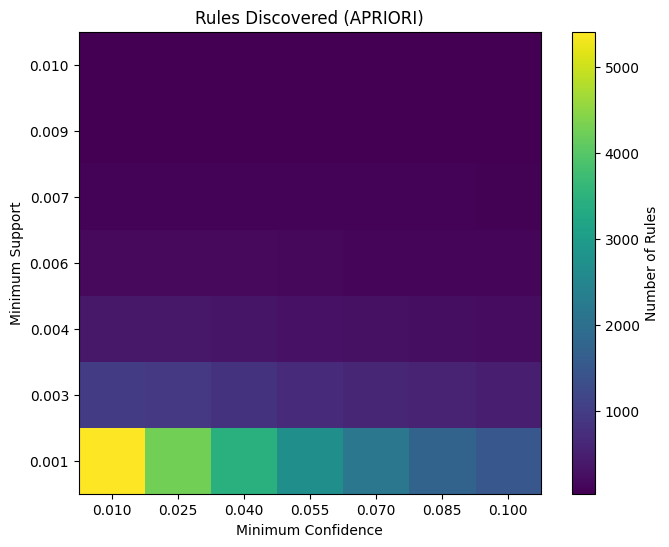

In [64]:
# Run experiments for Apriori
results_apriori, sups, confs = experiment_thresholds(transactions_csv, algorithm='apriori')


FP_GROWTH | min_sup=0.0010, min_conf=0.0100 => 5414 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.0250 => 4274 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.0400 => 3447 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.0550 => 2715 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.0700 => 2160 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.0850 => 1751 rules
FP_GROWTH | min_sup=0.0010, min_conf=0.1000 => 1502 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0100 => 975 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0250 => 917 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0400 => 816 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0550 => 689 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0700 => 604 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.0850 => 542 rules
FP_GROWTH | min_sup=0.0025, min_conf=0.1000 => 481 rules
FP_GROWTH | min_sup=0.0040, min_conf=0.0100 => 375 rules
FP_GROWTH | min_sup=0.0040, min_conf=0.0250 => 375 rules
FP_GROWTH | min_sup=0.0040, min_conf=0.0400 => 339 rules
FP_GROWTH | min_sup=0.00

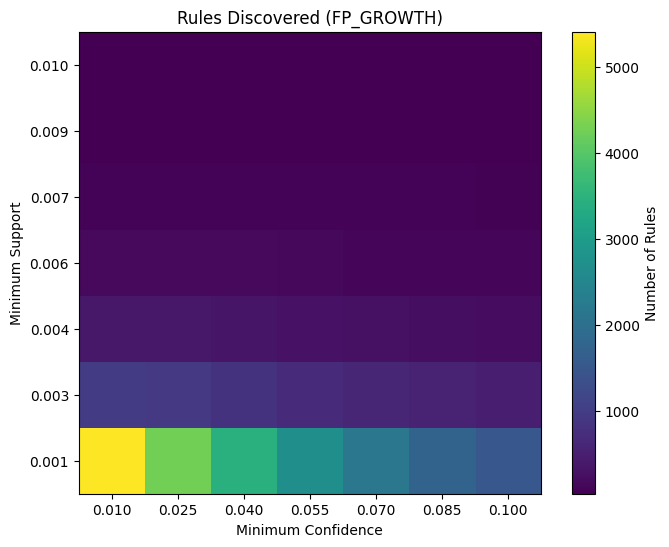

In [65]:
# Run experiments for FP-Growth
results_fpg, sups, confs = experiment_thresholds(transactions_csv, algorithm='fp_growth')

**Optimal Values:**
min_sup = 0.004 min_conf = 0.05

## Part C: Recommendation and Evaluation

In [66]:
# opt_min_sup = 0.004
# opt_min_conf = 0.05

# # ---- FP-GROWTH ----
# print("\nRunning FP-Growth ...")
# fpg_freq_sets_c, T2_c = fpgrowth(transactions_csv, min_support=opt_min_sup)
# print("FP-Growth discovered {} frequent itemsets".format(len(fpg_freq_sets_c)))

# fpg_rules_c = generate_rules_singleton_antecedent(fpg_freq_sets_c, T2_c, min_confidence=opt_min_conf)
# print("FP-Growth produced {} rules with singleton antecedent (min_confidence={})".format(len(fpg_rules_c), opt_min_conf))

# df_fpg_c = pd.DataFrame(fpg_rules_c)
# df_fpg_c = df_fpg_c.sort_values(by=["support", "confidence"], ascending=[False, False]).reset_index(drop=True)

# # ------------------------------
# # Top 100 by support & confidence
# # ------------------------------
# top100_support = df_fpg_c.nlargest(100, "support")
# top100_conf = df_fpg_c.nlargest(100, "confidence")

# top100_support.to_csv("5_top100RulesBySup.txt", sep='\t', index=False)
# top100_conf.to_csv("5_top100RulesByConf.txt", sep='\t', index=False)
# df_fpg_c.to_csv('fpgrowth_rules.csv', index=False)

# print(f"\nSaved top 100 rules by support to 5_top100RulesBySup.txt")
# print(f"Saved top 100 rules by confidence to 5_top100RulesByConf.txt")
# print("\nFP-Growth rules saved to fpgrowth_rules.csv")

# # ---- FIND COMMON RULES ----
# # We'll match by (antecedent, consequent)
# sup_set = set(zip(top100_support["antecedent"], top100_support["consequent"]))
# conf_set = set(zip(top100_conf["antecedent"], top100_conf["consequent"]))

# common_rules = sup_set.intersection(conf_set)

# print(f"\nNumber of common rules in both top 100 lists: {len(common_rules)}")
# print("\nCommon Rules:")
# for ant, cons in common_rules:
#     print(f"  {{{ant}}} -> {cons}")

In [67]:


# ---- Load product names ----
products = pd.read_csv('products.csv')
product_map = dict(zip(products['product_id'], products['product_name']))

def map_to_names_safe(item):
    """
    Convert antecedent/consequent (which may be int, list, set, tuple, or string)
    into readable product names.
    """
    if isinstance(item, (int, np.integer)):
        return product_map.get(int(item), f"Unknown({item})")

    if isinstance(item, (list, set, tuple)):
        ids = [int(i) for i in item]
        return ", ".join([product_map.get(i, f"Unknown({i})") for i in ids])

    # Handle strings like "{21137}", "('21137',)" or "21137, 24852"
    s = str(item)
    for ch in "{}()'":
        s = s.replace(ch, "")
    ids = [i.strip() for i in s.split(",") if i.strip().isdigit()]
    return ", ".join([product_map.get(int(i), f"Unknown({i})") for i in ids])


# ---- FP-GROWTH ----
opt_min_sup = 0.004
opt_min_conf = 0.05

print("\nRunning FP-Growth ...")
fpg_freq_sets_c, T2_c = fpgrowth(transactions_csv, min_support=opt_min_sup)
print("FP-Growth discovered {} frequent itemsets".format(len(fpg_freq_sets_c)))

fpg_rules_c = generate_rules_singleton_antecedent(fpg_freq_sets_c, T2_c, min_confidence=opt_min_conf)
print("FP-Growth produced {} rules with singleton antecedent (min_confidence={})".format(len(fpg_rules_c), opt_min_conf))

df_fpg_c = pd.DataFrame(fpg_rules_c)
df_fpg_c = df_fpg_c.sort_values(by=["support", "confidence"], ascending=[False, False]).reset_index(drop=True)

# ------------------------------
# Add mapped product names
# ------------------------------
df_fpg_c["antecedent_name"] = df_fpg_c["antecedent"].apply(map_to_names_safe)
df_fpg_c["consequent_name"] = df_fpg_c["consequent"].apply(map_to_names_safe)

# ------------------------------
# Top 100 by support & confidence
# ------------------------------
top100_support = df_fpg_c.nlargest(100, "support").reset_index(drop=True)
top100_conf = df_fpg_c.nlargest(100, "confidence").reset_index(drop=True)

# Add readable name columns to both
top100_support["antecedent_name"] = top100_support["antecedent"].apply(map_to_names_safe)
top100_support["consequent_name"] = top100_support["consequent"].apply(map_to_names_safe)

top100_conf["antecedent_name"] = top100_conf["antecedent"].apply(map_to_names_safe)
top100_conf["consequent_name"] = top100_conf["consequent"].apply(map_to_names_safe)

# Save all with names
top100_support.to_csv("5_top100RulesBySup.txt", sep='\t', index=False)
top100_conf.to_csv("5_top100RulesByConf.txt", sep='\t', index=False)
df_fpg_c.to_csv('fpgrowth_rules.csv', index=False)

print(f"\nSaved top 100 rules by support to 5_top100RulesBySup.txt (with product names)")
print(f"Saved top 100 rules by confidence to 5_top100RulesByConf.txt (with product names)")
print("\nFP-Growth rules saved to fpgrowth_rules.csv (with product names)")

# ---- FIND COMMON RULES ----
sup_set = set(zip(top100_support["antecedent"], top100_support["consequent"]))
conf_set = set(zip(top100_conf["antecedent"], top100_conf["consequent"]))
common_rules = sup_set.intersection(conf_set)

print(f"\nNumber of common rules in both top 100 lists: {len(common_rules)}")
print("\nCommon Rules (mapped to product names):")
for ant, cons in common_rules:
    ant_names = map_to_names_safe(ant)
    cons_names = map_to_names_safe(cons)
    print(f"  {{{ant_names}}} → {{{cons_names}}}")

# ---- Save common rules with names ----
common_rules_named = []
for ant, cons in common_rules:
    common_rules_named.append({
        "antecedent_id": ant,
        "consequent_id": cons,
        "antecedent_name": map_to_names_safe(ant),
        "consequent_name": map_to_names_safe(cons)
    })
pd.DataFrame(common_rules_named).to_csv("5_commonRulesMapped.csv", index=False)
print("\nSaved: 5_commonRulesMapped.csv (with product names)")



Running FP-Growth ...
FP-Growth discovered 540 frequent itemsets
FP-Growth produced 315 rules with singleton antecedent (min_confidence=0.05)

Saved top 100 rules by support to 5_top100RulesBySup.txt (with product names)
Saved top 100 rules by confidence to 5_top100RulesByConf.txt (with product names)

FP-Growth rules saved to fpgrowth_rules.csv (with product names)

Number of common rules in both top 100 lists: 39

Common Rules (mapped to product names):
  {Organic Raspberries} → {Organic Strawberries}
  {Organic Hass Avocado} → {Organic Strawberries}
  {Organic Garlic} → {Bag of Organic Bananas}
  {Organic Cilantro} → {Limes}
  {Organic Baby Spinach} → {Banana}
  {Limes} → {Banana}
  {Organic Blueberries} → {Bag of Organic Bananas}
  {Organic Cucumber} → {Bag of Organic Bananas}
  {Limes} → {Large Lemon}
  {Yellow Onions} → {Banana}
  {Organic Zucchini} → {Bag of Organic Bananas}
  {Organic Whole Milk} → {Organic Strawberries}
  {Organic Strawberries} → {Banana}
  {Strawberries} → {

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# ----------------------------------------------------------
# 2️⃣  Helper: Build rule dictionary
# ----------------------------------------------------------
def build_rule_dict(rules):
    """
    rules: list of dicts with keys 'antecedent', 'consequent'
    returns: dict mapping frozenset(antecedent) -> set(consequent)
    """
    rule_dict = {}
    for r in rules:
        ant = frozenset([str(r['antecedent']).strip().lower()])
        cons = set([str(c).strip().lower() for c in r['consequent']])
        if ant not in rule_dict:
            rule_dict[ant] = set()
        rule_dict[ant].update(cons)
    return rule_dict

# ----------------------------------------------------------
# 3️⃣  Evaluate recommendations
# ----------------------------------------------------------
def evaluate_recommendations(rule_dict, test_transactions, max_k=10):
    avg_precisions = []
    avg_recalls = []
    user_precisions = []
    user_recalls = []

    for k in range(1, max_k + 1):
        precisions = []
        recalls = []

        for t in test_transactions:
            if len(t) < 2:
                continue

            half = len(t) // 2
            input_items = [i.strip().lower() for i in t[:half]]
            ground_truth = set([i.strip().lower() for i in t[half:]])

            # Predict items using rules
            predicted = set()
            for item in input_items:
                ant = frozenset([item])
                if ant in rule_dict:
                    predicted.update(rule_dict[ant])

            # Take top-k predicted
            predicted_topk = set(list(predicted)[:k])

            if not predicted_topk:
                precisions.append(0)
                recalls.append(0)
                continue

            intersection = len(predicted_topk & ground_truth)
            precision = intersection / len(predicted_topk)
            recall = intersection / len(ground_truth)

            precisions.append(precision)
            recalls.append(recall)

        avg_precisions.append(np.mean(precisions) if precisions else 0)
        avg_recalls.append(np.mean(recalls) if recalls else 0)
        user_precisions.append(precisions)
        user_recalls.append(recalls)

    return avg_precisions, avg_recalls, user_precisions, user_recalls


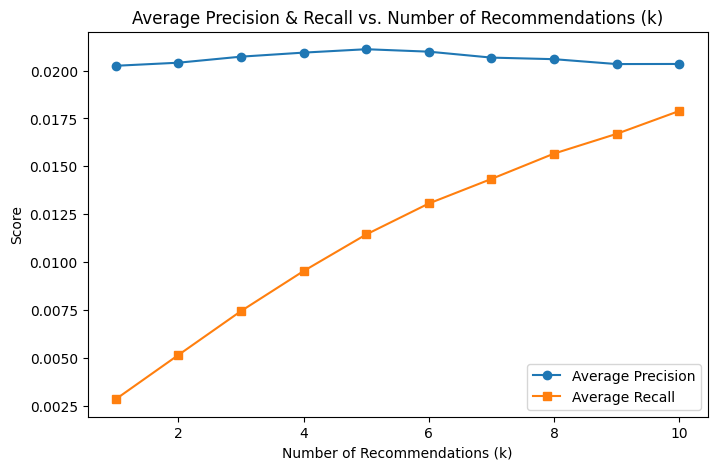

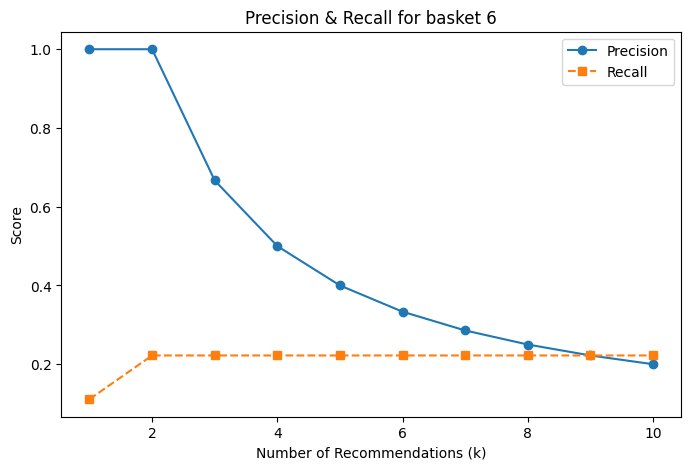

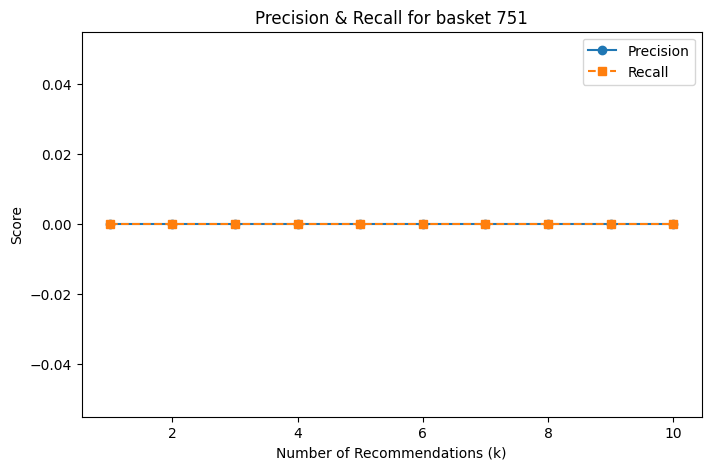

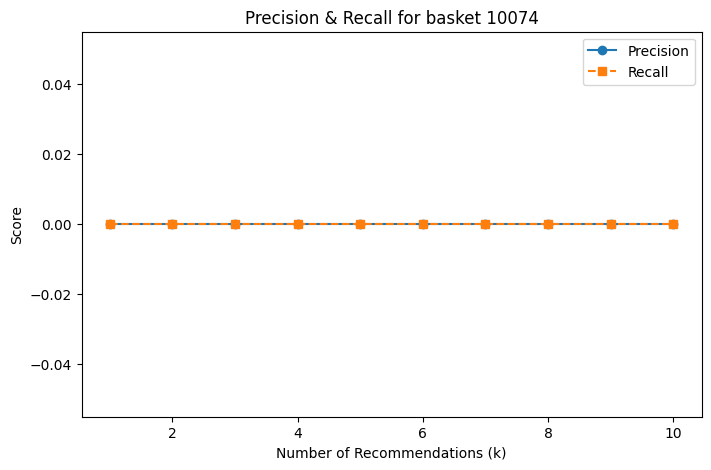

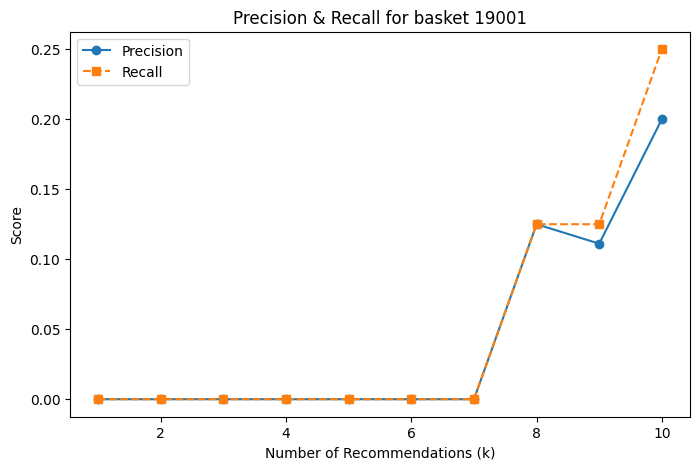

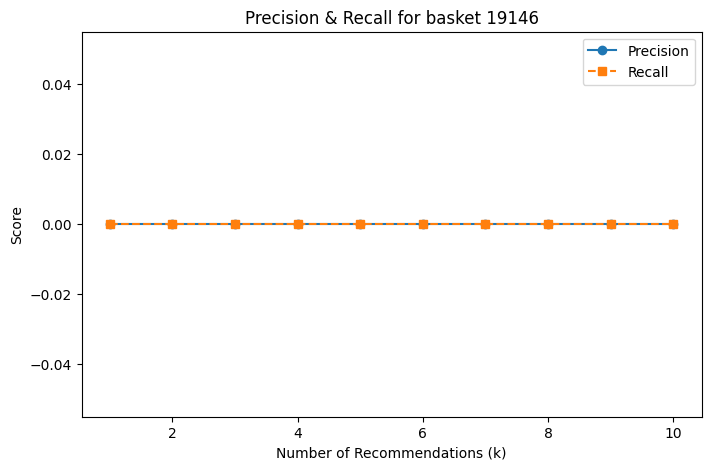

In [69]:

# Build rule dictionary from your FP-Growth output
rule_dict = build_rule_dict(fpg_rules_c)
# Load test transactions
test_df = pd.read_csv("transactions_test.csv")

# If your test CSV doesn't have a single "product_id" column,
# rebuild transactions from other columns (example below)
if "product_id" in test_df.columns:
    test_transactions = test_df["product_id"].apply(lambda x: [i.strip().lower() for i in str(x).split(",")])
else:
    # assume each row represents one transaction with product columns (e.g., prod_1, prod_2, ...)
    test_transactions = test_df.apply(lambda row: [str(i).strip().lower() for i in row.dropna().values if str(i).strip() != ""], axis=1)

test_transactions = [t for t in test_transactions if len(t) >= 2]  # remove short baskets

# ----------------------------------------------------------
# 4️⃣  Run evaluation
# ----------------------------------------------------------
avg_prec, avg_rec, user_prec, user_rec = evaluate_recommendations(rule_dict, test_transactions)


# ----------------------------------------------------------
# 5️⃣  Plot Average Precision & Recall
# ----------------------------------------------------------
k_values = list(range(1, 11))
plt.figure(figsize=(8, 5))
plt.plot(k_values, avg_prec, marker='o', label='Average Precision')
plt.plot(k_values, avg_rec, marker='s', label='Average Recall')
plt.xlabel("Number of Recommendations (k)")
plt.ylabel("Score")
plt.title("Average Precision & Recall vs. Number of Recommendations (k)")
plt.legend()
plt.show()
8
# ----------------------------------------------------------
# 6️⃣  Plot sample users' precision/recall (5 random users)
# ----------------------------------------------------------
sample_indices =[5, 750, 10073, 19000,19145]

for idx in sample_indices:
    user_prec_vals = [user_prec[k - 1][idx] if idx < len(user_prec[k - 1]) else 0 for k in k_values]
    user_rec_vals = [user_rec[k - 1][idx] if idx < len(user_rec[k - 1]) else 0 for k in k_values]

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, user_prec_vals, marker='o', linestyle='-', label='Precision')
    plt.plot(k_values, user_rec_vals, marker='s', linestyle='--', label='Recall')
    plt.xlabel("Number of Recommendations (k)")
    plt.ylabel("Score")
    plt.title(f"Precision & Recall for basket {idx+1}")
    plt.legend()
    plt.show()


